# 5 - Ratings Analysis

Analyzes user ratings from the piki database across generations, song popularity, and release decade. Based on the fairness analysis in Fairness-Github.ipynb but loaded directly from the database.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)

%run db.py

## Load ratings from the database

Combines:
- `user_songs` (seq=0 → like, seq=2 → superlike)
- `unliked_songs` (dislike)

Joined with `catalog` for song metadata and `users` for generation.

In [29]:
sql = """
SELECT
    r.timestamp,
    r.user_id,
    r.song_id,
    r.liked,
    pop_decile as spotify_popularity,
    year as release_year,
    generation,
    gender
FROM (
    SELECT timestamp, user_id, song_id,
           CASE WHEN seq = 2 THEN 2 ELSE 1 END AS liked
    FROM user_songs
    WHERE timestamp >= '2020-01-01'

    UNION ALL

    SELECT timestamp, user_id, song_id, 0 AS liked
    FROM unliked_songs
    WHERE timestamp >= '2020-01-01'
) r
JOIN catalog c ON c.id = r.song_id
join artists a on c.artist_id=a.id
join release_dates rd on c.id=rd.song_id
LEFT JOIN users u ON u.id = r.user_id
left join user_generation ug on u.id=ug.user_id 
left join user_genders ud on u.id=ud.user_id
WHERE pop_decile IS NOT NULL
  AND year IS NOT NULL
"""

rows = DB.fetch(sql)
df = pd.DataFrame(rows)
print(f"{len(df):,} ratings, {df['user_id'].nunique():,} users, {df['song_id'].nunique():,} songs")
df.head()

5,981,647 ratings, 19,282 users, 242,063 songs


,timestamp,user_id,song_id,liked,spotify_popularity,release_year,generation,gender
0,2021-08-02 08:51:20,3731419,1,1,50,2012,None,None
1,2021-12-22 16:58:32,3739644,1,1,50,2012,None,unknown
2,2025-12-15 06:29:54,3748865,1,1,50,2012,Gen Z,Male
3,2025-04-24 13:45:41,3749452,1,1,50,2012,Gen X,Male
4,2025-12-07 19:37:17,3753093,1,1,50,2012,Gen Z,male


## Feature engineering

In [30]:
# Binary like / superlike flags
df['like_rate']      = (df['liked'] == 1).astype(int)
df['superlike_rate'] = (df['liked'] == 2).astype(int)
df['positive_rate']  = (df['liked'] >= 1).astype(int)  # like or superlike

# Decade bins
df['release_decade']    = (df['release_year'] // 10 * 10).astype(int)
df['popularity_decile'] = (df['spotify_popularity'] // 10 * 10).astype(int)

# Normalize generation
df['generation'] = df['generation'].fillna('Unknown')

# Normalize gender: lowercase, map known values, bucket the rest as Unknown
df['gender'] = (
    df['gender']
    .fillna('unknown')
    .str.lower()
    .str.strip()
    .map(lambda g: 'Male' if g == 'male' else ('Female' if g == 'female' else 'Unknown'))
)

print("Rating distribution:")
print(df['liked'].value_counts().sort_index().rename({0: 'Dislike', 1: 'Like', 2: 'Superlike'}))
print()
print("Generation distribution:")
print(df['generation'].value_counts())
print()
print("Gender distribution:")
print(df['gender'].value_counts())

Rating distribution:
liked
Dislike      2670309
Like         2532491
Superlike     778847
Name: count, dtype: int64

Generation distribution:
generation
Unknown      4790437
Gen Z         502746
Gen X         402686
Millenial     285778
Name: count, dtype: int64

Gender distribution:
gender
Male       2503399
Unknown    2293418
Female     1184830
Name: count, dtype: int64


## Dataset overview

In [31]:
print(f"Total ratings:       {len(df):>10,}")
print(f"Unique users:        {df['user_id'].nunique():>10,}")
print(f"Unique songs:        {df['song_id'].nunique():>10,}")
print(f"Date range:          {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Avg spotify_pop:     {df['spotify_popularity'].mean():>10.1f} (std {df['spotify_popularity'].std():.1f})")
print(f"Avg release_year:    {df['release_year'].mean():>10.1f} (std {df['release_year'].std():.1f})")
print(f"Overall like rate:   {df['like_rate'].mean():>10.1%}")
print(f"Overall superlike:   {df['superlike_rate'].mean():>10.1%}")

Total ratings:        5,981,647
Unique users:            19,282
Unique songs:           242,063
Date range:          2020-01-01 19:36:37 → 2026-03-21 02:17:55
Avg spotify_pop:           59.6 (std 18.4)
Avg release_year:        2006.6 (std 14.9)
Overall like rate:        42.3%
Overall superlike:        13.0%


## Like rate by generation

In [32]:
gen_stats = df.groupby('generation').agg(
    n=('liked', 'count'),
    like_rate=('like_rate', 'mean'),
    superlike_rate=('superlike_rate', 'mean'),
    positive_rate=('positive_rate', 'mean'),
).sort_values('n', ascending=False)

gen_stats['like_rate']      = gen_stats['like_rate'].map('{:.1%}'.format)
gen_stats['superlike_rate'] = gen_stats['superlike_rate'].map('{:.1%}'.format)
gen_stats['positive_rate']  = gen_stats['positive_rate'].map('{:.1%}'.format)
gen_stats['n']              = gen_stats['n'].map('{:,}'.format)
gen_stats

,n,like_rate,superlike_rate,positive_rate
generation,,,,
Unknown,"4,790,437",42.7%,11.1%,53.8%
Gen Z,"502,746",38.8%,21.3%,60.0%
Gen X,"402,686",37.8%,22.6%,60.4%
Millenial,"285,778",49.5%,16.9%,66.4%


## Like rate by gender

In [33]:
gender_stats = df.groupby('gender').agg(
    n=('liked', 'count'),
    like_rate=('like_rate', 'mean'),
    superlike_rate=('superlike_rate', 'mean'),
    positive_rate=('positive_rate', 'mean'),
).sort_values('n', ascending=False)

gender_stats['like_rate']      = gender_stats['like_rate'].map('{:.1%}'.format)
gender_stats['superlike_rate'] = gender_stats['superlike_rate'].map('{:.1%}'.format)
gender_stats['positive_rate']  = gender_stats['positive_rate'].map('{:.1%}'.format)
gender_stats['n']              = gender_stats['n'].map('{:,}'.format)
gender_stats

,n,like_rate,superlike_rate,positive_rate
gender,,,,
Male,"2,503,399",40.2%,13.7%,53.8%
Unknown,"2,293,418",44.0%,12.6%,56.6%
Female,"1,184,830",43.8%,12.5%,56.3%


## Rating composition by gender (stacked bar)

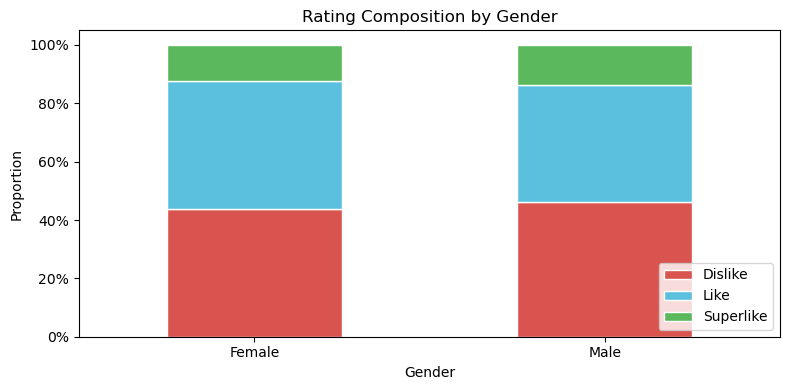

In [34]:
gender_crosstab = pd.crosstab(
    df['gender'],
    df['liked'],
    normalize='index'
).rename(columns={0: 'Dislike', 1: 'Like', 2: 'Superlike'})
# Show only known genders
gender_crosstab = gender_crosstab.loc[gender_crosstab.index != 'Unknown']

ax = gender_crosstab.plot(kind='bar', stacked=True, figsize=(8, 4),
                          color=['#d9534f', '#5bc0de', '#5cb85c'], edgecolor='white')
ax.set_xlabel('Gender')
ax.set_ylabel('Proportion')
ax.set_title('Rating Composition by Gender')
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Like rate by popularity decile, split by gender

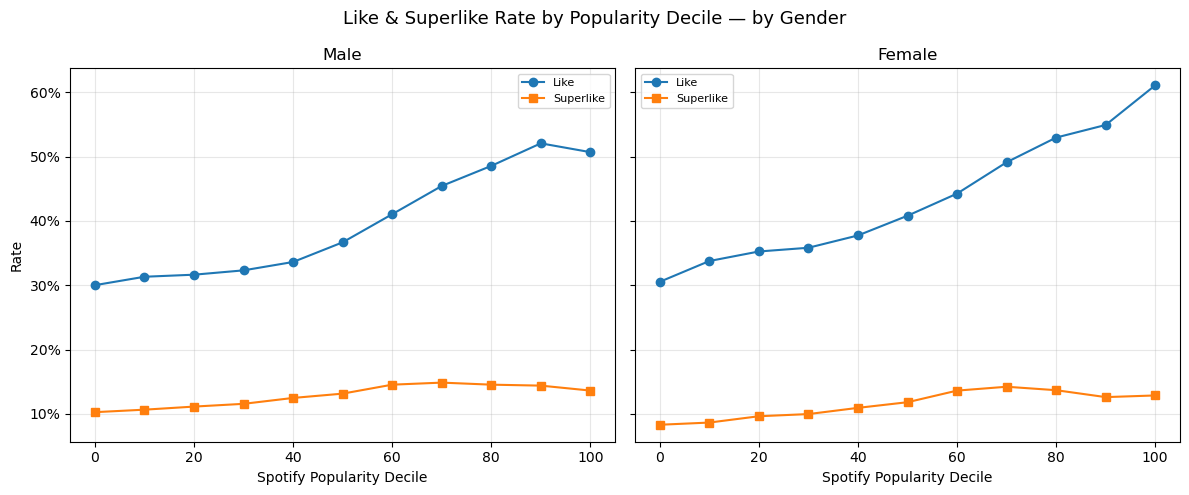

In [35]:
genders_known = ['Male', 'Female']
df_known = df[df['gender'].isin(genders_known)]

fig, axes = plt.subplots(1, len(genders_known), figsize=(6 * len(genders_known), 5), sharey=True)

for ax, gen in zip(axes, genders_known):
    sub = df_known[df_known['gender'] == gen].groupby('popularity_decile').agg(
        n=('liked', 'count'),
        like_rate=('like_rate', 'mean'),
        superlike_rate=('superlike_rate', 'mean'),
    ).reset_index()
    sub = sub[sub['n'] > 50]
    ax.plot(sub['popularity_decile'], sub['like_rate'],      marker='o', label='Like')
    ax.plot(sub['popularity_decile'], sub['superlike_rate'], marker='s', label='Superlike')
    ax.set_title(gen)
    ax.set_xlabel('Spotify Popularity Decile')
    ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Rate')
fig.suptitle('Like & Superlike Rate by Popularity Decile — by Gender', fontsize=13)
plt.tight_layout()
plt.show()

## Like rate by release decade, split by gender

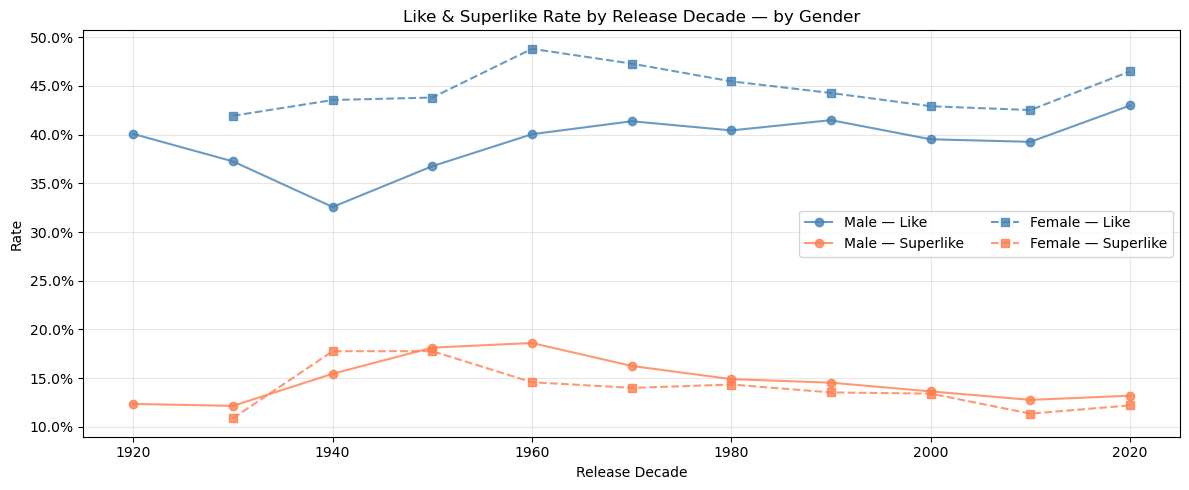

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))

for gen, style in zip(genders_known, [('-', 'o'), ('--', 's')]):
    linestyle, marker = style
    sub = df_known[df_known['gender'] == gen].groupby('release_decade').agg(
        n=('liked', 'count'),
        like_rate=('like_rate', 'mean'),
        superlike_rate=('superlike_rate', 'mean'),
    ).reset_index()
    sub = sub[sub['n'] > 200]
    ax.plot(sub['release_decade'], sub['like_rate'],
            linestyle=linestyle, marker=marker, color='steelblue',
            label=f'{gen} — Like', alpha=0.8)
    ax.plot(sub['release_decade'], sub['superlike_rate'],
            linestyle=linestyle, marker=marker, color='coral',
            label=f'{gen} — Superlike', alpha=0.8)

ax.set_xlabel('Release Decade')
ax.set_ylabel('Rate')
ax.set_title('Like & Superlike Rate by Release Decade — by Gender')
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
ax.legend(ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Like rate by popularity decile

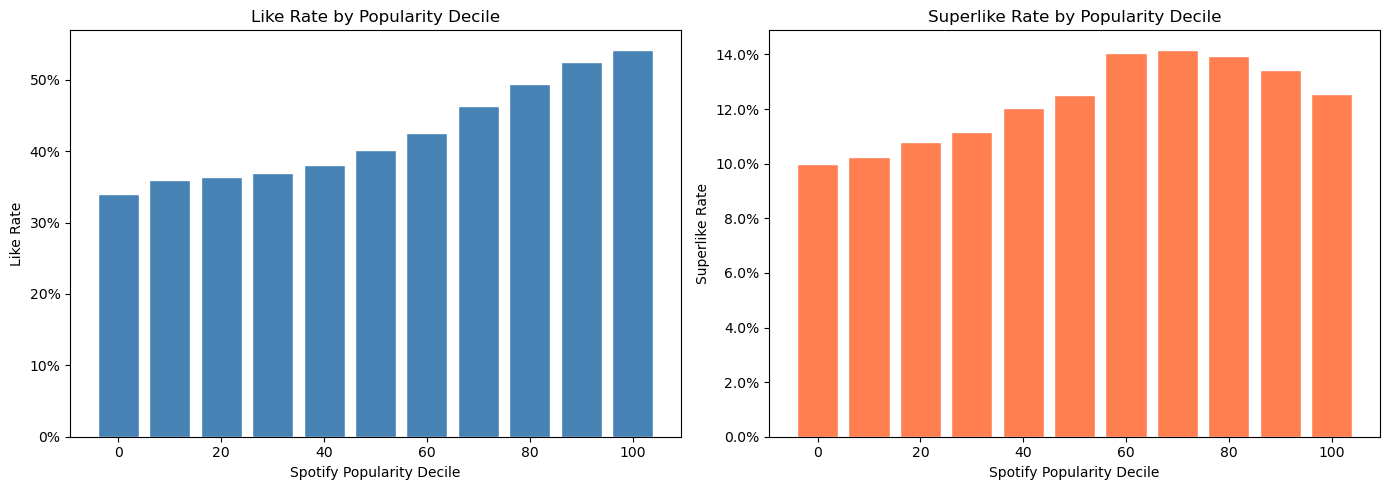

In [37]:
pop_stats = df.groupby('popularity_decile').agg(
    n=('liked', 'count'),
    like_rate=('like_rate', 'mean'),
    superlike_rate=('superlike_rate', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(pop_stats['popularity_decile'], pop_stats['like_rate'], width=8, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Spotify Popularity Decile')
axes[0].set_ylabel('Like Rate')
axes[0].set_title('Like Rate by Popularity Decile')
axes[0].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

axes[1].bar(pop_stats['popularity_decile'], pop_stats['superlike_rate'], width=8, color='coral', edgecolor='white')
axes[1].set_xlabel('Spotify Popularity Decile')
axes[1].set_ylabel('Superlike Rate')
axes[1].set_title('Superlike Rate by Popularity Decile')
axes[1].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## Like rate by release decade

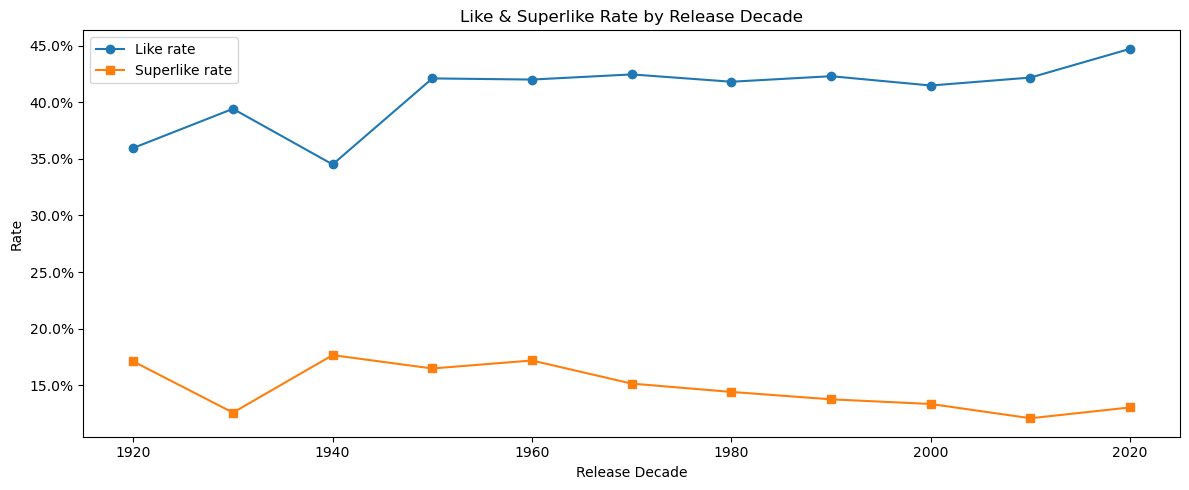

In [38]:
decade_stats = df.groupby('release_decade').agg(
    n=('liked', 'count'),
    like_rate=('like_rate', 'mean'),
    superlike_rate=('superlike_rate', 'mean'),
).reset_index()
decade_stats = decade_stats[decade_stats['n'] > 500]  # filter sparse decades

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(decade_stats['release_decade'], decade_stats['like_rate'],      marker='o', label='Like rate')
ax.plot(decade_stats['release_decade'], decade_stats['superlike_rate'], marker='s', label='Superlike rate')
ax.set_xlabel('Release Decade')
ax.set_ylabel('Rate')
ax.set_title('Like & Superlike Rate by Release Decade')
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

## Like rate by popularity decile, split by generation

## Rating composition by popularity decile (stacked bar)

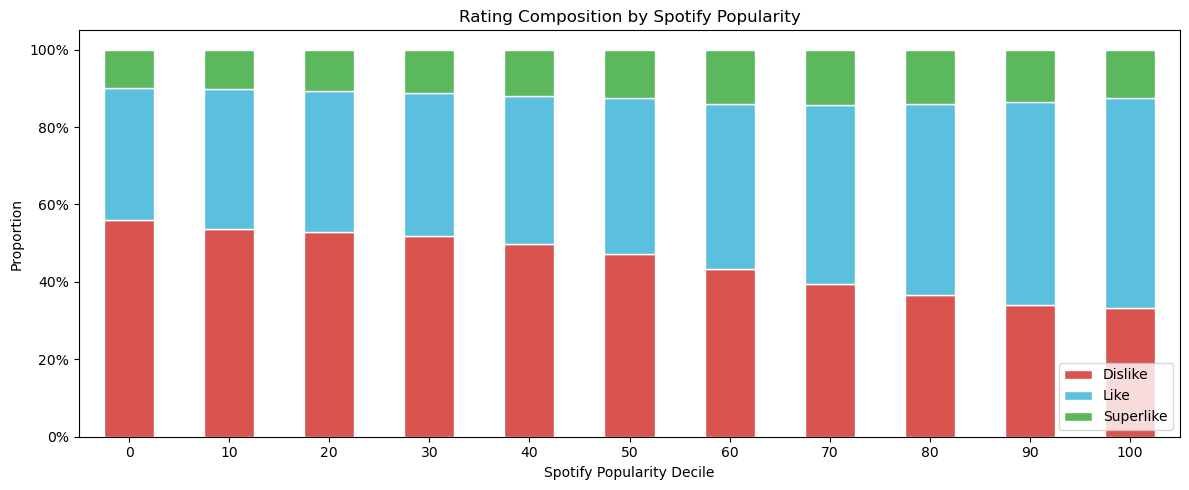

In [39]:
crosstab = pd.crosstab(
    df['popularity_decile'],
    df['liked'],
    normalize='index'
).rename(columns={0: 'Dislike', 1: 'Like', 2: 'Superlike'})

ax = crosstab.plot(kind='bar', stacked=True, figsize=(12, 5),
                   color=['#d9534f', '#5bc0de', '#5cb85c'], edgecolor='white')
ax.set_xlabel('Spotify Popularity Decile')
ax.set_ylabel('Proportion')
ax.set_title('Rating Composition by Spotify Popularity')
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Songs with most ratings

In [40]:
song_stats = df.groupby('song_id').agg(
    n=('liked', 'count'),
    like_rate=('like_rate', 'mean'),
    superlike_rate=('superlike_rate', 'mean'),
    spotify_popularity=('spotify_popularity', 'first'),
    release_year=('release_year', 'first'),
).sort_values('n', ascending=False)

print(f"Songs with > 200 ratings: {(song_stats['n'] > 200).sum()}")
song_stats.head(20)

Songs with > 200 ratings: 5231


,n,like_rate,superlike_rate,spotify_popularity,release_year
song_id,,,,,
540,3360,0.465476,0.179464,76,2004
2469655,2993,0.468092,0.128633,64,2017
1049,2648,0.509063,0.146903,85,2011
3463,2499,0.468587,0.171269,88,2002
13039,2449,0.508779,0.198857,79,1999
3813,2346,0.475703,0.184996,79,2005
7417,2338,0.457228,0.210009,78,2013
630,2307,0.462072,0.162115,88,2002
8150319,2293,0.460968,0.255560,79,2022
